<a href="https://colab.research.google.com/github/HadzhymuradovaAnzhela/python-sales-data-analysis/blob/main/Sales_and_Profitability_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.colab import drive
drive.mount ("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Data

/content/drive/MyDrive/Data


In [ ]:
countries = pd.read_csv("countries.csv")
countries = pd.DataFrame(countries)
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


Loading the countries.csv dataset, which serves as a geographical reference table. It is used to map country codes to their respective names, regions, and sub-regions.


In [ ]:
products = pd.read_csv("products.csv")
products = pd.DataFrame(products)
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


Loading the products.csv dataset, which acts as a product catalog.


In [ ]:
events = pd.read_csv("events.csv")
events = pd.DataFrame(events)
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


Loading the events.csv dataset, which is the primary transaction table. It contains core metrics, including order dates, shipping details, sales channels, and financial data. This dataset serves as the foundation for the entire analytical study.

#Data cleaning

## Cleaning the Country table

In [ ]:
countries.shape

(249, 5)

In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Identified null values in the alpha-2, region, and sub-region columns.

In [ ]:
countries[countries["alpha-2"].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
countries[countries["region"].isna()]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


In [ ]:
countries.loc[153, "alpha-2"] = "NA"
countries.loc[8, "region"] = "Antarctica"
countries.loc[8, "sub-region"] = "Antarctica"
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      249 non-null    object
 4   sub-region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Restored the "NA" ISO code for Namibia, which was incorrectly parsed as a null value during data loading. Populated missing regional data for Antarctica to ensure dataset completeness.

In [ ]:
duplicate_rows = countries.duplicated()
print(f"Count of duplicates: {duplicate_rows.sum()}")

Count of duplicates: 0


Confirmed the absence of duplicate rows, ensuring data uniqueness. Performed an initial data quality audit and handled missing values within the geographical reference table.



## Cleaning the Products table



In [ ]:
products["id"] = products["id"].astype(str)
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     object
 1   item_type  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes


In [ ]:
duplicate_rows_2 = products.duplicated()
print(f"Count of duplicates: {duplicate_rows_2.sum()}")

Count of duplicates: 0


Converted the id column to string format to ensure compatibility with the primary sales table during the joining process. Verified that the dataset contains no missing values or duplicate entries.


##Cleaning the Orders table


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


Missing values were identified in the Country Code and Units Sold columns.


In [ ]:
events.isna().sum() / events.shape[0] * 100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


Calculated the percentage of missing values using .isna().sum(). Since missing data in Units Sold accounts for only 0.15% of the dataset, these records were removed as their impact on the analysis is negligible. For the Country Code column, where 6% of values are missing, I applied a placeholder 'Unknown' to preserve the remaining transactional data. I performed column renaming and standardization to ensure a consistent naming convention

In [ ]:
events_clean = pd.DataFrame(events)
events_clean = events_clean[events_clean["Units Sold"].notna()]
events_clean.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_clean.columns = events_clean.columns.str.replace(" ", "_")
events_clean.head()

,Order_ID,Order_Date,Ship_Date,Order_Priority,Country_Code,Product_ID,Sales_Channel,Units_Sold,Unit_Price,Unit_Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_clean.loc[:, "Country_Code"] = events_clean["Country_Code"].fillna("Unknown")
events_clean.head()

,Order_ID,Order_Date,Ship_Date,Order_Priority,Country_Code,Product_ID,Sales_Channel,Units_Sold,Unit_Price,Unit_Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_clean["Order_Date"] = pd.to_datetime(events_clean["Order_Date"])
events_clean["Ship_Date"] = pd.to_datetime(events_clean["Ship_Date"])
events_clean["Order_ID"] = events_clean["Order_ID"].astype(str)
events_clean["Product_ID"] = events_clean["Product_ID"].astype(str)

In [ ]:
events_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1328 non-null   object        
 1   Order_Date      1328 non-null   datetime64[ns]
 2   Ship_Date       1328 non-null   datetime64[ns]
 3   Order_Priority  1328 non-null   object        
 4   Country_Code    1328 non-null   object        
 5   Product_ID      1328 non-null   object        
 6   Sales_Channel   1328 non-null   object        
 7   Units_Sold      1328 non-null   float64       
 8   Unit_Price      1328 non-null   float64       
 9   Unit_Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 146.4+ KB


In [ ]:
events_clean.loc[:, "Order_ID"] = events_clean["Order_ID"].astype(str).str.strip()

In [ ]:
duplicate_rows_3 = events_clean[events_clean.duplicated(subset=["Order_ID"], keep=False)]
duplicate_rows_3

,Order_ID,Order_Date,Ship_Date,Order_Priority,Country_Code,Product_ID,Sales_Channel,Units_Sold,Unit_Price,Unit_Cost


Converted date columns to datetime objects and identifiers to string format. To guarantee data integrity, I performed a duplicate check on the Order_ID column after applying string stripping to remove any leading or trailing whitespaces. No duplicate transactions were found, confirming the uniqueness of the order records.



In [ ]:
events_clean.describe()

,Order_Date,Ship_Date,Units_Sold,Unit_Price,Unit_Cost
count,1328,1328,1328.000000,1328.000000,1328.000000
mean,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,4952.201807,264.913245,187.211521
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000
25%,2011-12-14 06:00:00,2012-01-02 00:00:00,2356.750000,81.730000,35.840000
50%,2013-10-15 12:00:00,2013-11-05 12:00:00,4962.000000,154.060000,97.440000
75%,2015-08-29 12:00:00,2015-10-04 18:00:00,7459.500000,437.200000,263.330000
max,2017-07-23 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000
std,NaN,NaN,2905.198996,217.386320,176.187801


Detailed analysis of the distribution revealed that Units Sold range from 2 to 9 999, with mean and median values remaining closely aligned, indicating no significant anomalies. However, for Unit Price (9 \$ to 668 \$) and Unit Cost (6.9 \$ to 524 \$ ), the mean is significantly higher than the median. This indicates a right-skewed distribution, likely caused by a small number of premium high-ticket items. Despite this variance, no data entry errors or extreme outliers were found that would compromise the integrity of the analysis.

Text(0.6944444444444517, 0.5, 'Frequency')

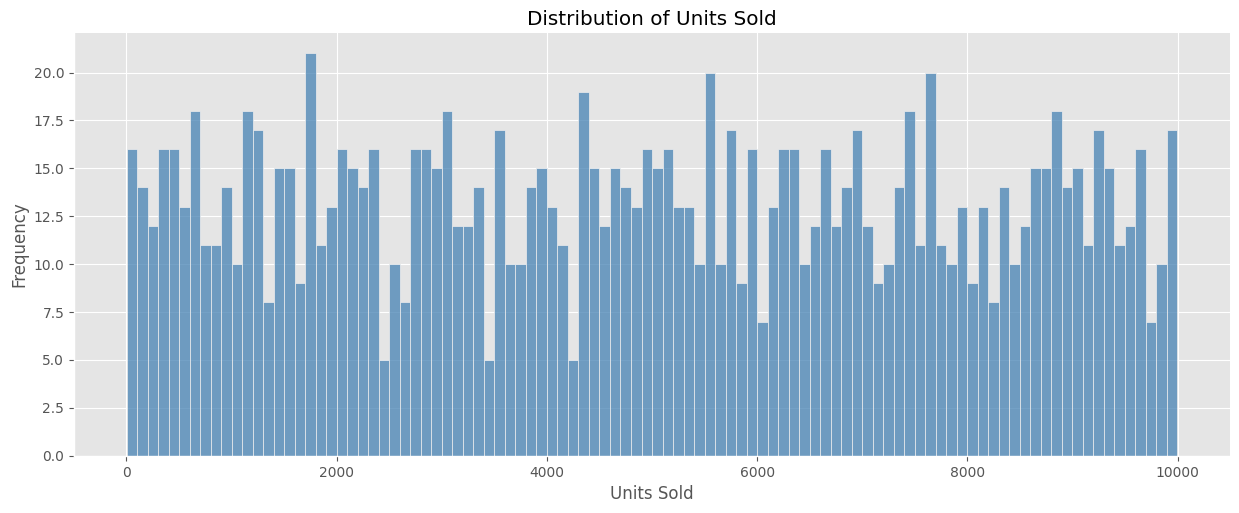

In [ ]:
plt.style.use('ggplot')
sns.displot(x="Units_Sold", data= events_clean, kind="hist", color="SteelBlue", bins=100, aspect=2.5)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")


The histogram illustrates a near-uniform distribution of the quantity of units sold per order. There is no dominant preference for a specific order size, as frequency remains relatively consistent across the entire range from small orders to large-scale transactions of up to 10 000 units. This suggests a diverse customer base with varied purchasing requirements.

Text(5.069444444444452, 0.5, 'Frequency')

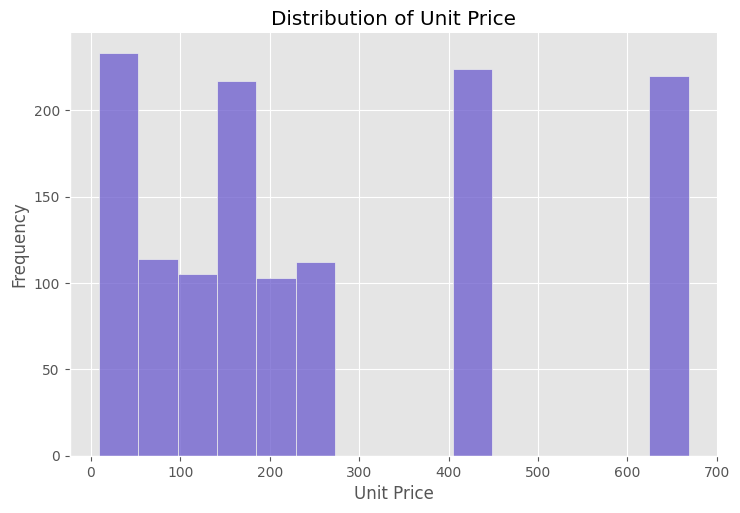

In [ ]:
sns.displot(x="Unit_Price", data= events_clean, kind="hist", color="SlateBlue", bins=15, aspect=1.5)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

The visual analysis of Unit Price reveals a multimodal distribution. While the majority of transactions are concentrated in the lower price segment, there are two distinct peaks at approximately 400 \$ and 650 \$. This suggests a strategic product segmentation, where the business offers a mix budget items alongside premium-tier products.

<a name="merging-tables"></a>
# Merging tables

In [ ]:
products.rename(columns={"id": "Product_ID"}, inplace=True)
countries.rename(columns={"alpha-3": "Country_Code"}, inplace=True)

In [ ]:
df_start = pd.merge(events_clean, products, on="Product_ID", how="left")
df = pd.merge(df_start, countries, on="Country_Code", how="left")
df.rename(columns={"item_type": "Product"}, inplace=True)
df.rename(columns={"name": "Country"}, inplace=True)
df.rename(columns={"region": "Region"}, inplace=True)
df.rename(columns={"sub-region": "Sub-region"}, inplace=True)
df["Sales_Channel"] = df["Sales_Channel"].str.capitalize()
df= df.drop("alpha-2", axis=1)
df["Revenue_M"] = df["Units_Sold"] * df["Unit_Price"]/1000000
df["Cost_M"] = df["Units_Sold"] * df["Unit_Cost"] /1000000
df["Profit_M"] = (df["Unit_Price"] - df["Unit_Cost"]) * df["Units_Sold"]/ 1000000
df["Lead_Time_in_days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days
df.head()

,Order_ID,Order_Date,Ship_Date,Order_Priority,Country_Code,Product_ID,Sales_Channel,Units_Sold,Unit_Price,Unit_Cost,Product,Country,Region,Sub-region,Revenue_M,Cost_M,Profit_M,Lead_Time_in_days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,0.133705,0.076121,0.057583,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,0.409960,0.233400,0.176560,0
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,3.136191,2.358420,0.777771,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,0.127967,0.041969,0.085998,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,0.362898,0.243130,0.119768,38


In [ ]:
df.describe()

,Order_Date,Ship_Date,Units_Sold,Unit_Price,Unit_Cost,Revenue_M,Cost_M,Profit_M,Lead_Time_in_days
count,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000
mean,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,4952.201807,264.913245,187.211521,1.281724,0.904138,0.377586,24.786898
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000,0.000504,0.000374,0.000130,0.000000
25%,2011-12-14 06:00:00,2012-01-02 00:00:00,2356.750000,81.730000,35.840000,0.266410,0.157607,0.084913,12.000000
50%,2013-10-15 12:00:00,2013-11-05 12:00:00,4962.000000,154.060000,97.440000,0.761305,0.433223,0.274868,25.000000
75%,2015-08-29 12:00:00,2015-10-04 18:00:00,7459.500000,437.200000,263.330000,1.743177,1.108768,0.547737,37.000000
max,2017-07-23 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000,6.672676,5.248025,1.700449,50.000000
std,NaN,NaN,2905.198996,217.386320,176.187801,1.443863,1.135504,0.369122,14.586041


I integrated the datasets into a single dataframe and calculated key metrics, including Revenue, Cost, Profit (in millions), and Lead Time. Order revenue ranges from 504 \$ to 6.67 million \$, with a significant 5 million \$ gap between the 75th percentile and the maximum, indicating that the mean is driven upward by a small number of high-value transactions. This right-skewed pattern is also reflected in cost and profit, where the maximum profit reached 1.7 million \$. Meanwhile, logistics metrics show a stable performance, with Lead Time ranging from 0 to 50 days and a mean value of 25 days, perfectly aligning with the median.


#Key Business Metrics

In [ ]:
print(f"Total Orders: {df.Order_ID.count()}")
print(f"Total Units Sold: {df.Units_Sold.sum()}")
print(f"Total Revenue in millions: {df.Revenue_M.sum():,.2f}")
print(f"Total Cost in millions: {df.Cost_M.sum():,.2f}")
print(f"Total Profit in millions: {df.Profit_M.sum():,.2f}")
print(f"Count of Countries: {df.Country.nunique()}")

Total Orders: 1328
Total Units Sold: 6576524.0
Total Revenue in millions: 1,702.13
Total Cost in millions: 1,200.69
Total Profit in millions: 501.43
Count of Countries: 45


#Sales Analysis by Category

In [ ]:
category = df.groupby("Product")[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Revenue_M"], ascending =False)
category.head()

,Product,Revenue_M,Cost_M,Profit_M
8,Office Supplies,402.213996,324.236819,77.977176
6,Household,294.205199,221.242732,72.962467
4,Cosmetics,233.154825,140.431519,92.723306
7,Meat,223.762018,193.424282,30.337736
0,Baby Food,143.647588,89.706591,53.940997


Text(0.5, 0, 'Revenue in millions ($)')

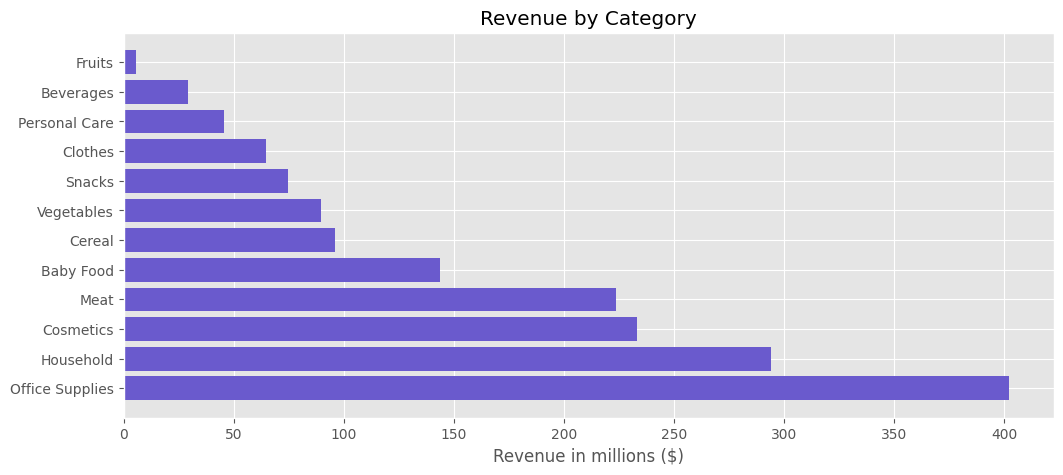

In [ ]:
plt.figure(figsize=(12, 5))
plt.barh(category["Product"], category["Revenue_M"], color ="SlateBlue")
plt.title("Revenue by Category")
plt.xlabel("Revenue in millions ($)")

The categorical analysis reveals that Office Supplies is the primary revenue driver, generating over 400 million \$. It is followed by Household goods at nearly 300 million \$, while Cosmetics and Meat share a strong performance with approximately 225 million \$ each. Baby Food rounds out the top five, whereas all other product categories contribute less than 100 million \$ to the total revenue. This distribution highlights a significant concentration of sales within the top five categories, which represent the core of the company's financial portfolio.

Text(0.5, 0, 'Cost in millions ($)')

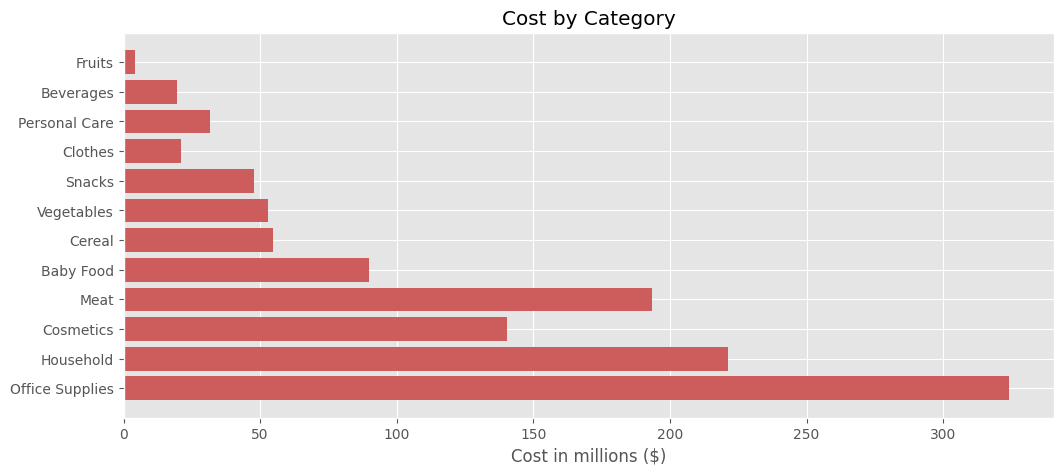

In [ ]:
plt.figure(figsize=(12, 5))
plt.barh(category["Product"], category["Cost_M"], color ="indianred")
plt.title("Cost by Category")
plt.xlabel("Cost in millions ($)")

The cost structure follows a similar trend to revenue for the top two categories, with Office Supplies and Household incurring costs of 325 million \$ and 210 million \$ respectively. A key insight emerges when comparing Cosmetics and Meat: while both categories generate similar revenue, the cost of goods sold for Cosmetics is approximately 50 million \$ lower than that of Meat. This significant variance suggests that Cosmetics operates on a much higher profit margin, making it a more financially efficient category for the business.

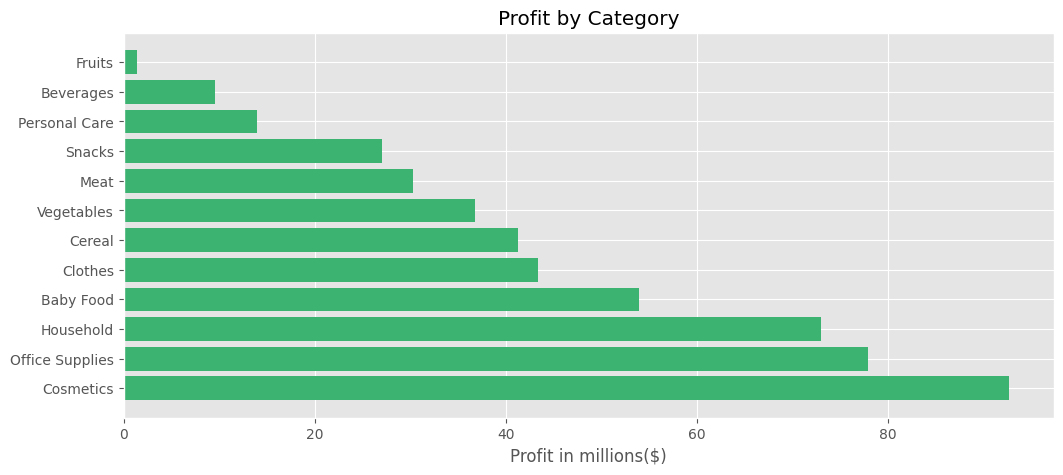

In [ ]:
category2 = df.groupby("Product")[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Profit_M"], ascending =False)
plt.figure(figsize=(12, 5))
plt.barh(category2["Product"], category2["Profit_M"], color ="mediumseagreen")
plt.title("Profit by Category")
plt.xlabel("Profit in millions($)")
plt.show()

The profitability analysis reveals that Cosmetics is the top-performing category, generating nearly 93 million $ in profit due to its low cost-to-revenue ratio, despite not having the highest gross sales. It is followed by the revenue leaders, Office Supplies and Household. Notably, Clothes secured a top-five position despite lower revenue, as its minimal costs resulted in high efficiency. Conversely, the Meat category dropped in the rankings because its high production and operational costs significantly diminished its overall profit margins.

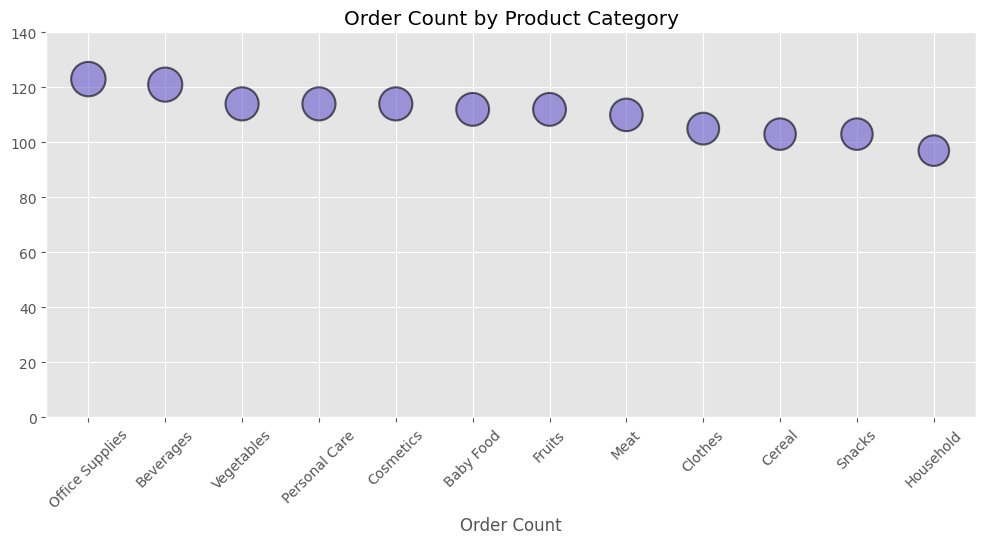

In [ ]:
category3 = df["Product"].value_counts().reset_index()
plt.figure(figsize=(12, 5))
plt.scatter(x=category3["Product"],y=category3["count"], color ="SlateBlue", s=category3["count"]*5, alpha=0.6, edgecolors="black", linewidth=1.5)
plt.title("Order Count by Product Category")
plt.xlabel("Order Count")
plt.xticks(rotation=45)
plt.ylim(ymin=0, ymax=140)
plt.show()

The order volume analysis shows a near-uniform distribution across all categories, with counts typically ranging from 100 to 120 orders, indicating no single dominant leader in terms of popularity. Interestingly, while Office Supplies records the highest number of transactions, the Household category has the lowest order count despite ranking third in total profit. This confirms that there is no direct correlation between order frequency and profitability, as further evidenced by the scatter plot below, suggesting that profit is driven more by high unit margins than by sheer transaction volume.

Text(0.5, 1.0, 'Correlation between Order Count and Profit by Category')

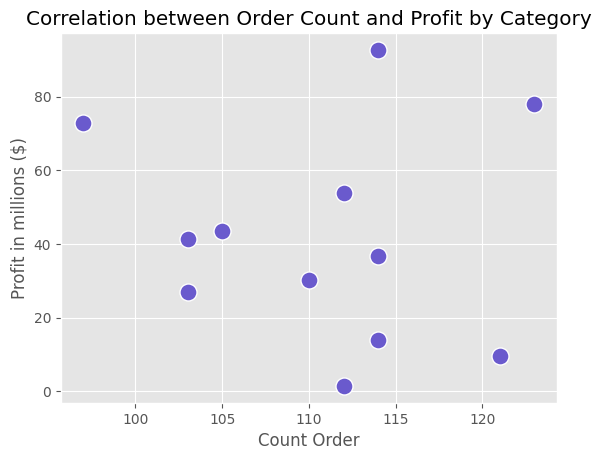

In [ ]:
for_scatter = pd.merge(category2, category3, on="Product", how="left")
sns.scatterplot(data=for_scatter, x="count", y="Profit_M", color="SlateBlue", marker = "o", s=150)
plt.xlabel("Count Order")
plt.ylabel("Profit in millions ($)")
plt.title("Correlation between Order Count and Profit by Category")

#Regional and Country-Level Sales Analysis

In [ ]:
country_gr = df.groupby(["Region", "Country"])[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Revenue_M"], ascending =False)
region_gr = df.groupby("Region")[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Revenue_M"], ascending =False)
country_gr.head()

,Region,Country,Revenue_M,Cost_M,Profit_M
11,Europe,Czech Republic,53.543932,39.908338,13.635594
43,Europe,Ukraine,53.252318,38.447392,14.804926
8,Europe,Bosnia and Herzegovina,50.117508,36.859906,13.257603
26,Europe,Macedonia,49.222085,35.537985,13.684100
36,Europe,San Marino,47.883708,34.090716,13.792993


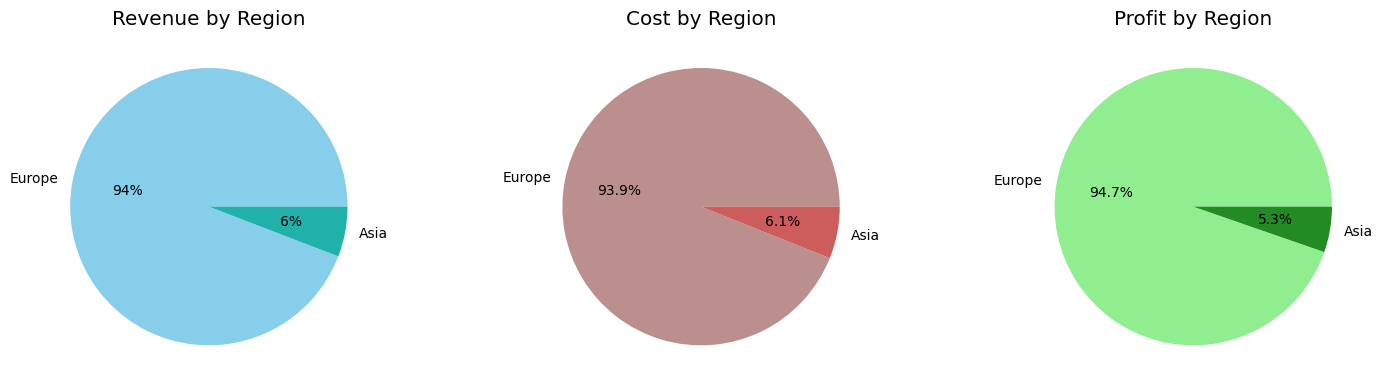

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (15, 4))

ax[0].pie(region_gr["Revenue_M"], labels=region_gr["Region"], autopct="%1.f%%", colors = ["skyblue", "lightseagreen"])
ax[0].set_title("Revenue by Region")
ax[1].pie(region_gr["Cost_M"], labels=region_gr["Region"], autopct="%1.1f%%", colors = ["rosybrown", "indianred"])
ax[1].set_title("Cost by Region")
ax[2].pie(region_gr["Profit_M"], labels=region_gr["Region"], autopct="%1.1f%%", colors = ["lightgreen", "forestgreen"])
ax[2].set_title("Profit by Region")
plt.tight_layout()

plt.show()

The Europe region significantly dominates in terms of Revenue and Profit. Revenue from European countries amounts to approximately 1 500 million \$, while the Asia region accounts for less than 100 million \$. Profit from Europe is around 450 million $, compared to only 20 million \$ from Asian countries. Therefore, expanding trade operations into Asian markets should be considered as a strategic opportunity.

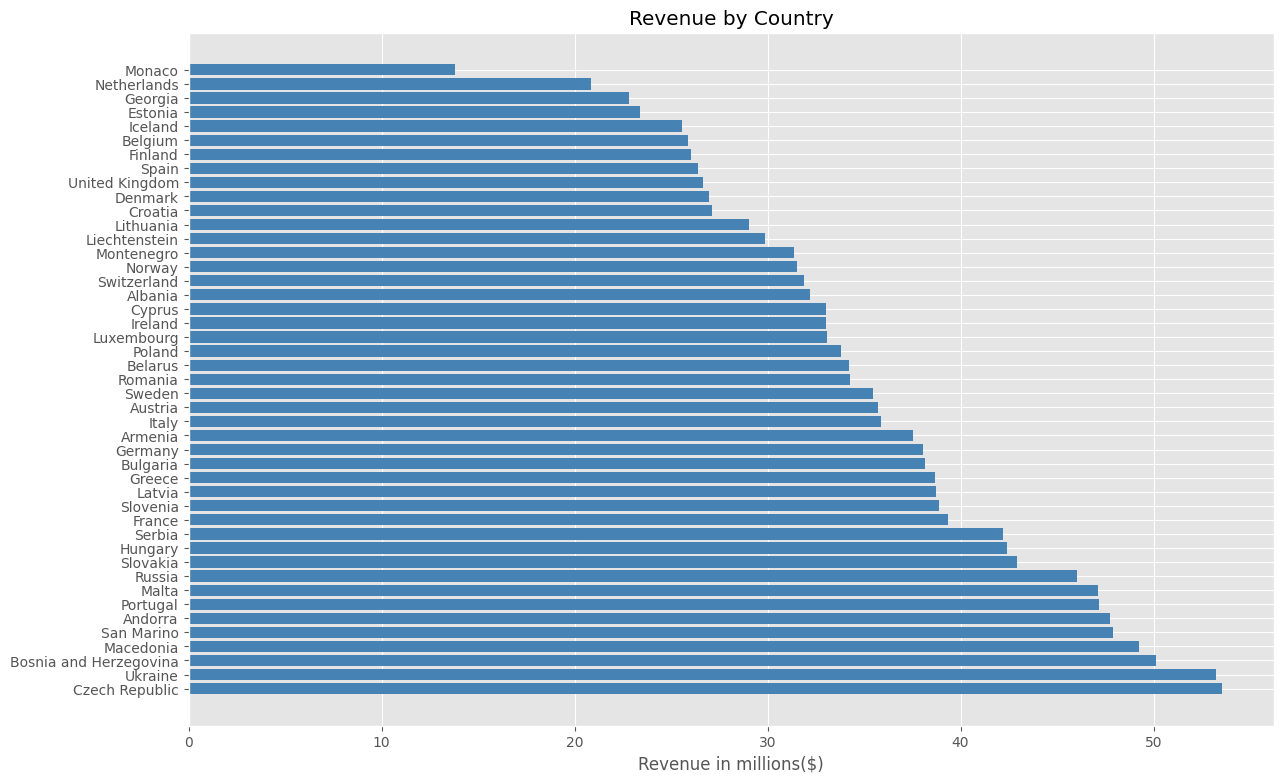

In [ ]:
plt.figure(figsize=(14, 9))
plt.barh(country_gr["Country"], country_gr["Revenue_M"], color ="steelblue")
plt.title("Revenue by Country")
plt.xlabel("Revenue in millions($)")
plt.show()

The leading countries generating the highest revenue include the Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino, Andorra, Portugal, Malta, Russia, Slovakia, Hungary, and Serbia, with revenue figures ranging from 40 to 55 million \$. In contrast, Monaco generates the lowest revenue, accounting for approximately 14 million \$

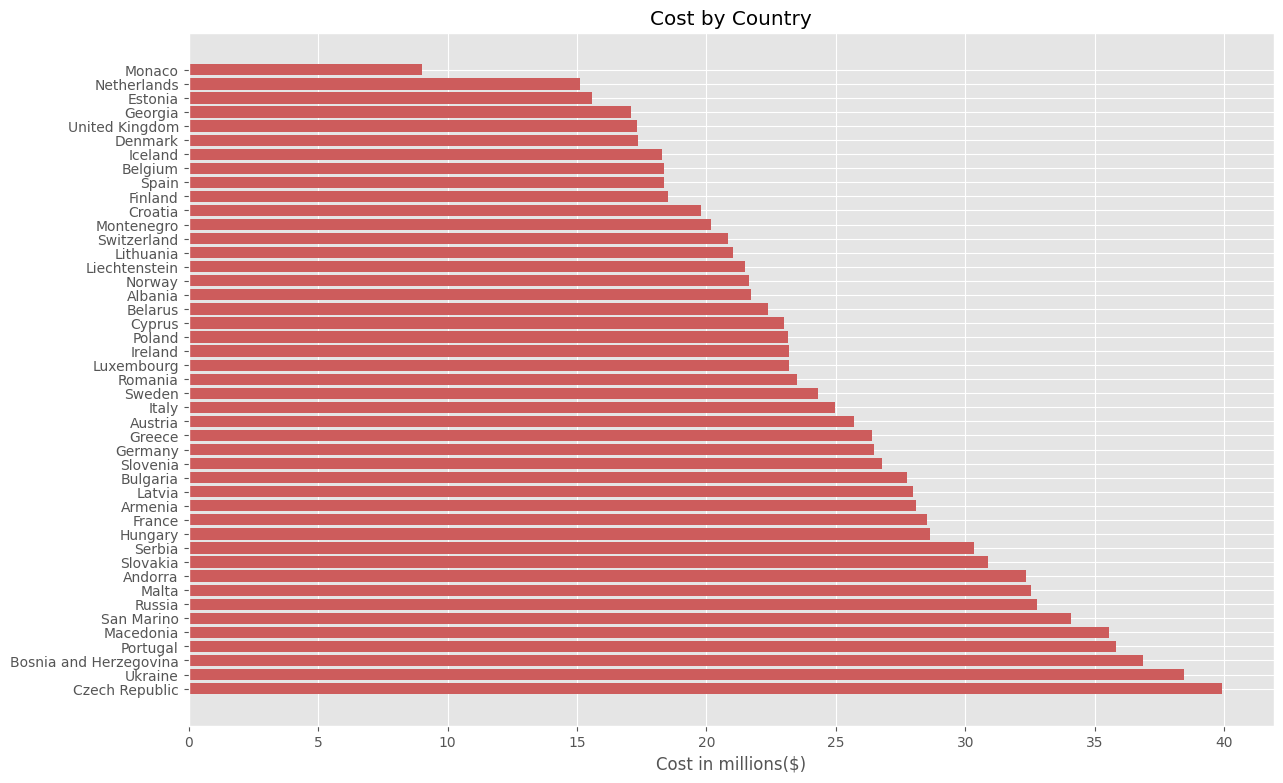

In [ ]:
country_gr_for_cost = df.groupby(["Region", "Country"])[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Cost_M"], ascending =False)
plt.figure(figsize=(14, 9))
plt.barh(country_gr_for_cost["Country"], country_gr_for_cost["Cost_M"], color ="indianred")
plt.title("Cost by Country")
plt.xlabel("Cost in millions($)")
plt.show()

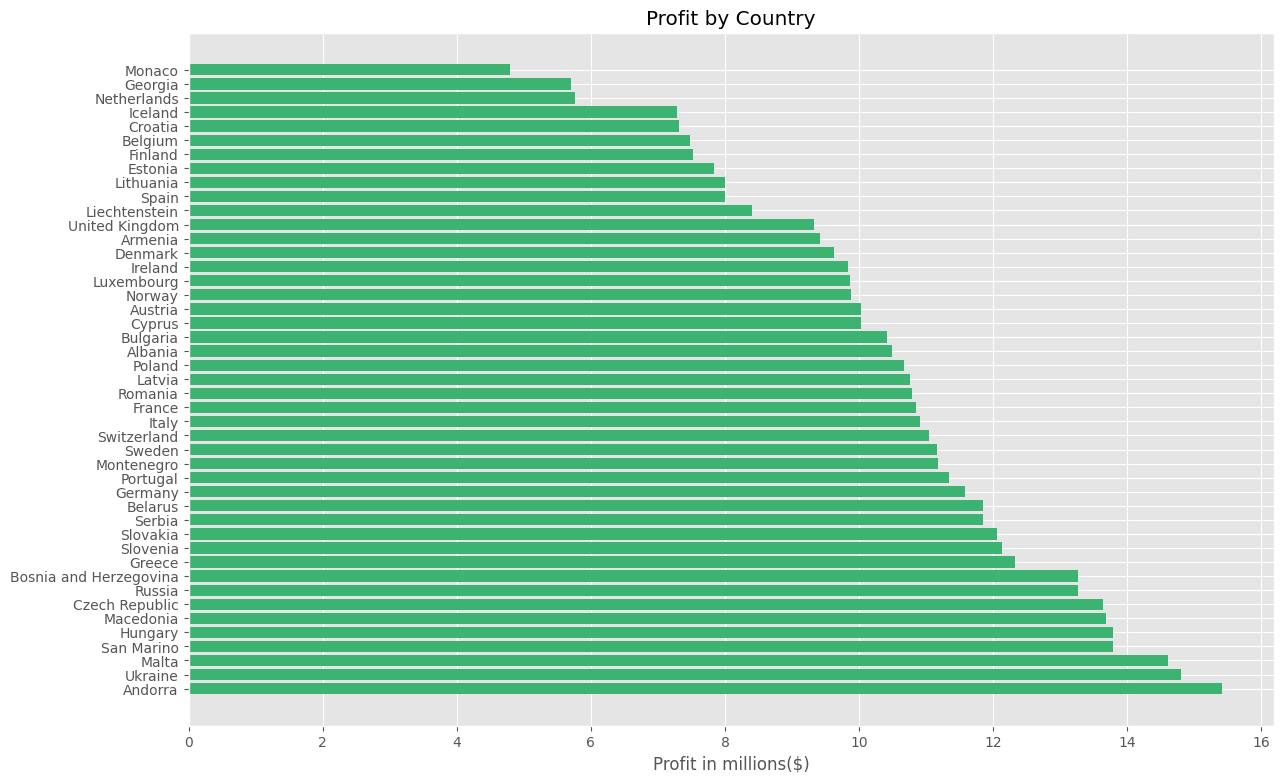

In [ ]:
country_gr_for_pr = df.groupby(["Region", "Country"])[["Profit_M"]].sum().reset_index().sort_values(["Profit_M"], ascending =False)
plt.figure(figsize=(14, 9))
plt.barh(country_gr_for_pr["Country"], country_gr_for_pr["Profit_M"], color ="mediumseagreen")
plt.title("Profit by Country")
plt.xlabel("Profit in millions($)")
plt.show()

The company generates the highest profit from trade with the following countries: Andorra, Ukraine, Malta, San Marino, Hungary, Macedonia, the Czech Republic, Russia, Bosnia and Herzegovina, Greece, Slovenia, and Slovakia, with profit figures ranging from 12 to 16 million \$. The lowest profit is recorded from Monaco. However, overall, there are no significantly low performance indicators across the dataset.

In [ ]:
country_alpha3 = df.groupby(["Country_Code", "Country"])[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Profit_M"], ascending =False)
fig = px.choropleth(country_alpha3,
                    locations="Country_Code",
                    color="Profit_M",
                    hover_name="Country",
                    hover_data=["Revenue_M", "Cost_M"],
                    projection="natural earth",
                    color_continuous_scale=px.colors.sequential.Cividis,
                    title="Profit by Country in millions($)")
fig.update_geos(
    lataxis_range=[30, 80],
    lonaxis_range=[-20, 170],
    visible=False
)
fig.show()

In [ ]:
country_cnt_order = df.groupby(["Country_Code", "Country"])["Order_ID"].count().reset_index()
fig = px.choropleth(country_cnt_order,
                    locations="Country_Code",
                    color="Order_ID",
                    hover_name="Country",
                    projection="natural earth",
                    color_continuous_scale=px.colors.sequential.PuBuGn,
                    title="Order Distribution by Country")
fig.update_geos(
    lataxis_range=[30, 80],
    lonaxis_range=[-20, 170],
    visible=False
)
fig.show()

The highest number of orders were placed in the following countries: San Marino and Andorra (40 orders each), followed by Romania, Bosnia and Herzegovina, Russia, Malta, Greece, Macedonia, and the Czech Republic, with 30 to 35 orders. As expected, Monaco recorded the lowest order volume.

#Sales Channel Performance Analysis

In [ ]:
channel_gr1 = df.groupby("Sales_Channel")[["Revenue_M","Cost_M", "Profit_M"]].sum().reset_index().sort_values(["Revenue_M"], ascending =False)
channel_cnt_order = df["Sales_Channel"].value_counts().reset_index()
channel_gr = pd.merge(channel_gr1, channel_cnt_order, on="Sales_Channel", how="left")
channel_gr

,Sales_Channel,Revenue_M,Cost_M,Profit_M,count
0,Offline,871.760624,618.294105,253.466519,665
1,Online,830.368784,582.400844,247.967940,663


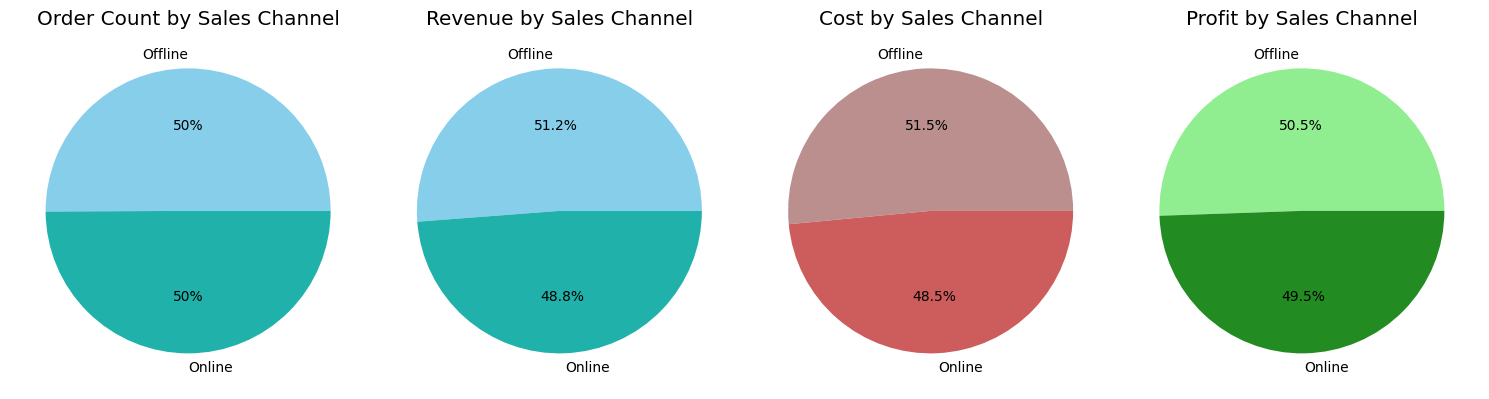

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15, 4))

ax[0].pie(channel_gr["count"], labels=channel_gr["Sales_Channel"], autopct="%1.f%%", colors = ["skyblue", "lightseagreen"])
ax[0].set_title("Order Count by Sales Channel")
ax[1].pie( channel_gr["Revenue_M"], labels=channel_gr["Sales_Channel"], autopct="%1.1f%%", colors = ["skyblue", "lightseagreen"])
ax[1].set_title("Revenue by Sales Channel")
ax[2].pie(channel_gr["Cost_M"], labels=channel_gr["Sales_Channel"], autopct="%1.1f%%", colors = ["rosybrown", "indianred"])
ax[2].set_title("Cost by Sales Channel")
ax[3].pie(channel_gr["Profit_M"], labels=channel_gr["Sales_Channel"], autopct="%1.1f%%", colors = ["lightgreen", "forestgreen"] )
ax[3].set_title("Profit by Sales Channel")
plt.tight_layout()
plt.show()

In general, the distribution of orders between Offline and Online channels is uniform. Revenue from Offline orders amounts to 870 million \$, which is 50 million \$ higher than Revenue from Online orders. However, the advantage of Offline orders in terms of Profit narrows to only 5 million \$, due to the higher costs associated with the Offline sales channel.

#Shipping Time Analysis by Product Category

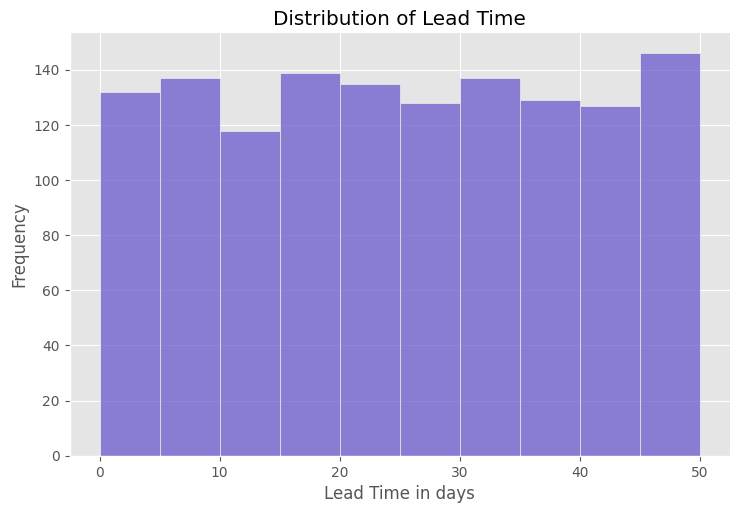

In [ ]:
sns.displot(x="Lead_Time_in_days", data= df, kind="hist", color = "Slateblue", bins=10, aspect=1.5)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time in days")
plt.ylabel("Frequency")
plt.show()

The distribution of order volume by lead time is nearly uniform. There is a significant share of orders delivered within 5 days, as well as a comparable proportion of orders with a delivery time ranging from 45 to 50 days.

In [ ]:
category_lead = df.groupby("Product")["Lead_Time_in_days"].agg(["median", "min", "max"]).reset_index().sort_values(["median"], ascending =False)
category_lead.head()

,Product,median,min,max
2,Cereal,29.0,0,50
0,Baby Food,28.5,0,50
4,Cosmetics,28.0,0,50
8,Office Supplies,27.0,1,50
10,Snacks,25.0,0,49


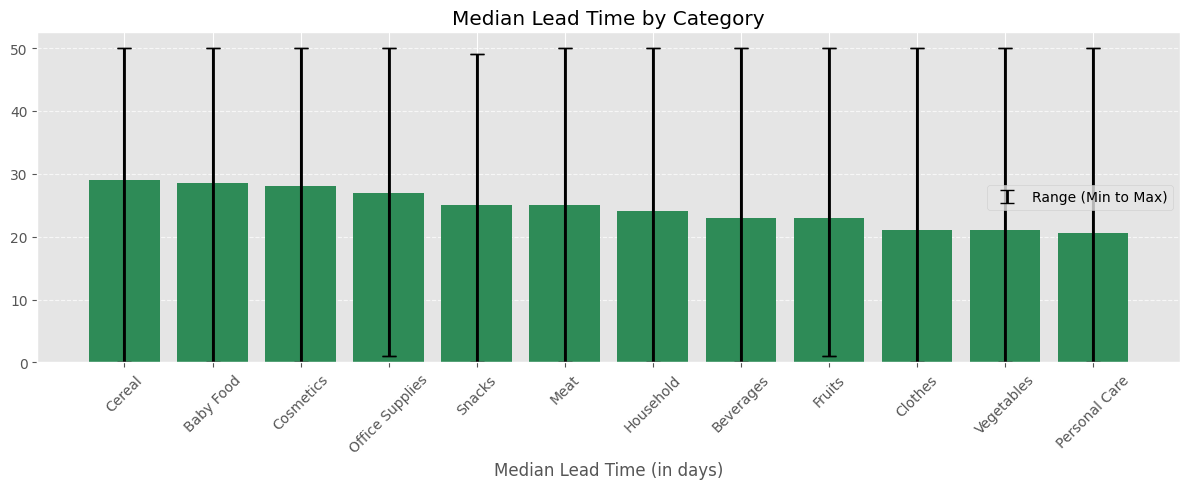

In [ ]:
plt.figure(figsize=(12, 5))
lower_error = category_lead["median"] - category_lead["min"]
upper_error = category_lead["max"] - category_lead["median"]
error_bars = np.array([lower_error, upper_error])
plt.bar(category_lead["Product"], category_lead["median"], color ="SeaGreen", yerr=error_bars, capsize=5)
plt.errorbar(
    x=category_lead["Product"],
    y=category_lead["median"],
    yerr=error_bars,
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=2,
    label="Range (Min to Max)"
)
plt.title("Median Lead Time by Category")
plt.xlabel("Median Lead Time (in days)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

As shown in the chart, the median delivery time across categories fluctuates between 21 and 29 days. The fastest deliveries are observed in the Personal Care, Vegetables, and Clothes categories, while Cereal, Baby Food, and Cosmetics exhibit the longest lead times. Interestingly, the range for each category is at its maximum - spanning from 0 or 1 to 50 days - which indicates that delivery time is independent of the product category.

#Lead Time Analysis by Country

In [ ]:
country_lead = df.groupby(["Country_Code", "Country"])["Lead_Time_in_days"].agg(["median", "min", "max"]).reset_index().sort_values(["median"], ascending =False)
country_lead.head()

,Country_Code,Country,median,min,max
21,HUN,Hungary,36.0,2,50
38,RUS,Russia,34.0,0,50
29,MCO,Monaco,33.0,5,48
18,GEO,Georgia,32.0,7,47
41,SVK,Slovakia,32.0,3,50


In [ ]:
fig = px.choropleth(country_lead,
                    locations="Country_Code",
                    color="median",
                    hover_name="Country",
                    hover_data=["max", "min"],
                    projection="natural earth",
                    color_continuous_scale=px.colors.sequential.Cividis,
                    title="Lead Time by Country(in days)")
fig.update_geos(
    lataxis_range=[30, 80],
    lonaxis_range=[-20, 170],
    visible=False
)
fig.show()

The longest median delivery times are recorded for Hungary, Russia, Monaco, Georgia, Slovakia, Finland, and Luxembourg, averaging over 30 days. Conversely, the shortest delivery times are observed in Liechtenstein, the United Kingdom, Portugal, and Macedonia, with medians under 20 days. The delivery time range remains broad for nearly every country, and no clear correlation was found between geographic location and lead time. For instance, Serbia has an average delivery time of 18 days, despite being adjacent to Hungary, where the average lead time reaches 36 days.

In [ ]:
region_lead = df.groupby("Sub-region")["Lead_Time_in_days"].agg(["median", "min", "max"]).reset_index().sort_values(["median"], ascending =False)
region_lead

,Sub-region,median,min,max
0,Eastern Europe,29.0,0,50
4,Western Europe,26.0,0,50
3,Western Asia,25.5,1,50
2,Southern Europe,23.0,0,50
1,Northern Europe,21.0,0,50


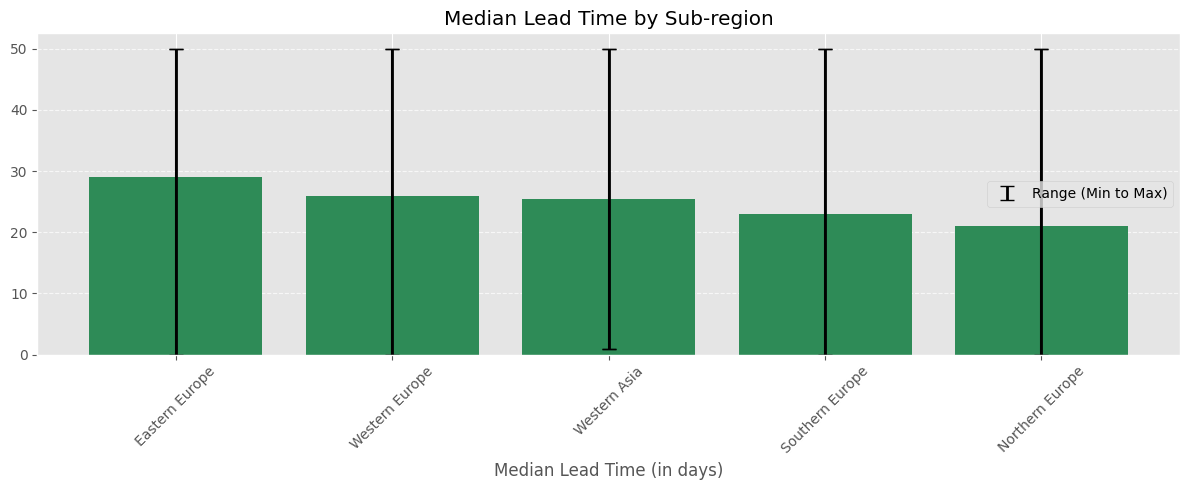

In [ ]:
plt.figure(figsize=(12, 5))
lower_error = region_lead["median"] - region_lead["min"]
upper_error = region_lead["max"] - region_lead["median"]
error_bars = np.array([lower_error, upper_error])
plt.bar(region_lead["Sub-region"], region_lead["median"], color ="SeaGreen", yerr=error_bars, capsize=5)
plt.errorbar(
    x=region_lead["Sub-region"],
    y=region_lead["median"],
    yerr=error_bars,
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=2,
    label="Range (Min to Max)"
)
plt.title("Median Lead Time by Sub-region")
plt.xlabel("Median Lead Time (in days)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

The analysis of average delivery times by region demonstrates that Northern Europe and Southern Europe receive goods the fastest, with medians of 21 and 23 days, respectively. In contrast, Eastern Europe and Western Europe exhibit the longest lead times, averaging 29 and 26 days. Western Asia receives orders in 26 days on average. It is worth noting that the delivery time ranges across sub-regions are, as expected, nearly at their maximum, spanning from 0 to 50 days.

#Correlation Between Profit and Lead Time

Text(0, 0.5, 'Profit in millions($)')

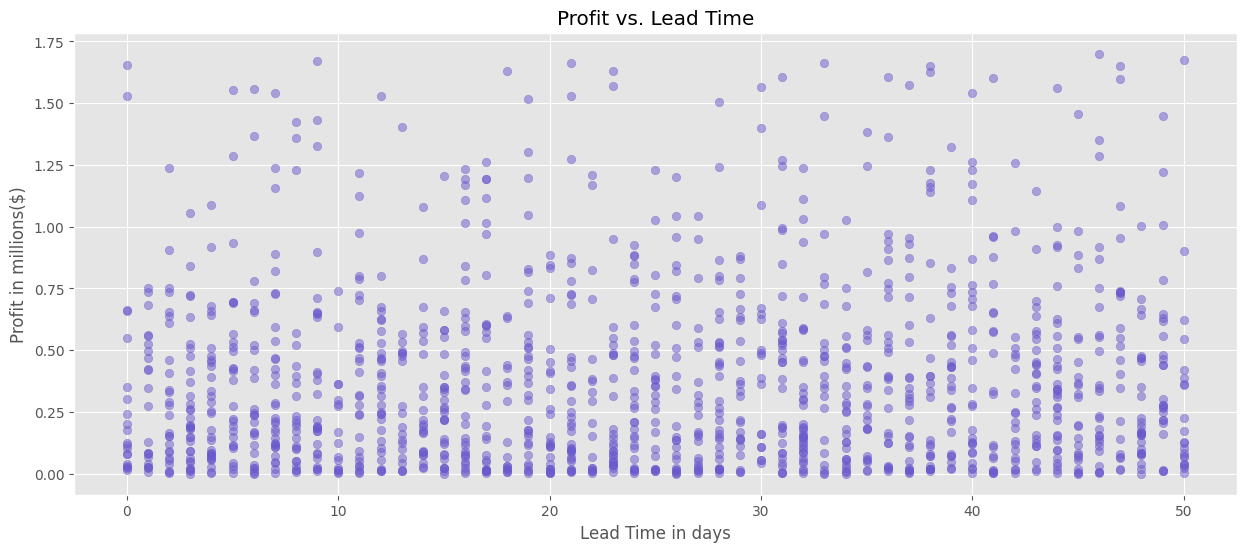

In [ ]:
plt.figure(figsize=(15,6))
plt.scatter(df["Lead_Time_in_days"], df["Profit_M"], alpha=0.5, color = "slateblue")
plt.title("Profit vs. Lead Time")
plt.xlabel("Lead Time in days")
plt.ylabel("Profit in millions($)")

The chart demonstrates a lack of linear correlation between lead time and profit. This indicates that orders with longer fulfillment times do not necessarily generate higher or lower profits compared to those completed quickly. Orders are distributed fairly evenly across the entire lead time range, with no significant clustering observed.

#Sales Dynamics and Temporal Trends

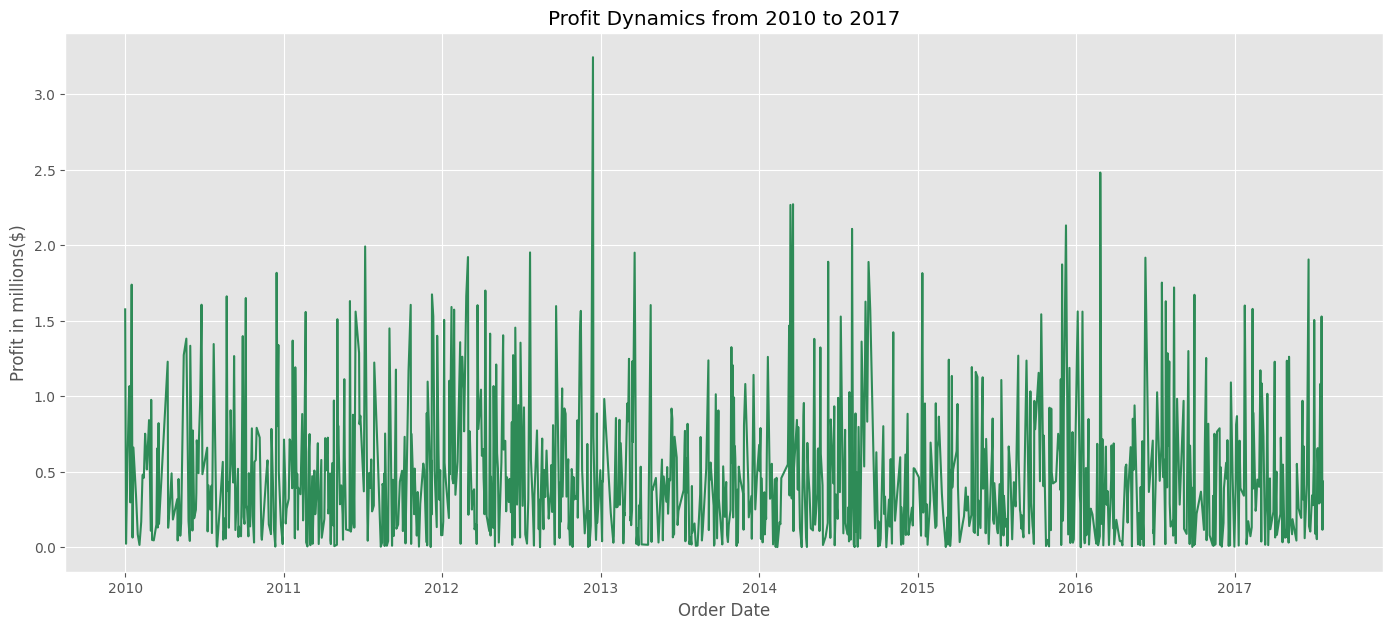

In [ ]:
date_gr = df.groupby("Order_Date")["Profit_M"].sum().reset_index()
plt.figure(figsize=(17, 7))
plt.plot(date_gr["Order_Date"], date_gr["Profit_M"], color="SeaGreen")
plt.title("Profit Dynamics from 2010 to 2017")
plt.xlabel("Order Date")
plt.ylabel("Profit in millions($)")
plt.show()

The sales dynamics over the years demonstrate seasonality, likely on both a weekly and annual basis. Performance figures are notably high at the beginning of each year. The peak performance occurred in 2012, reaching over 3 million $ in a single day, followed by relatively low indicators during 2013–2014. Overall, despite these fluctuations, the distribution is characterized by relative consistency and a clear seasonal dependency.

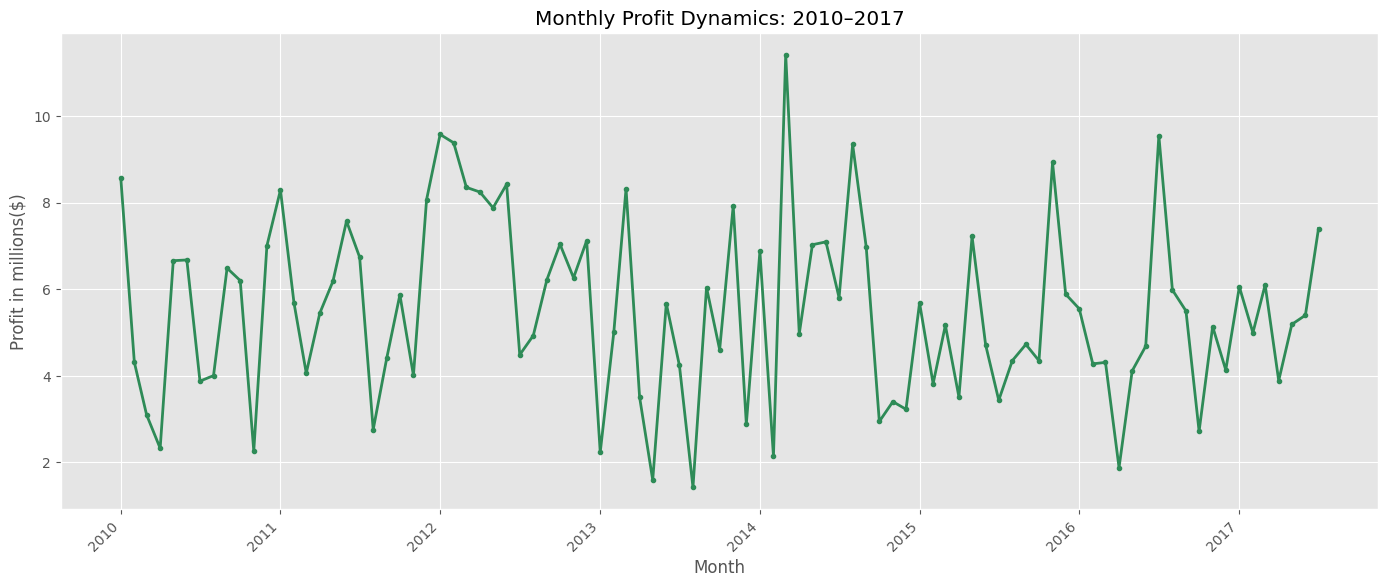

In [ ]:
df2=pd.DataFrame(df)
year_m_gr = df2.groupby(df2["Order_Date"].dt.to_period("M"))["Profit_M"].sum().reset_index()
year_m_gr["Order_Date"] = year_m_gr["Order_Date"].dt.to_timestamp()
plt.figure(figsize=(17, 7))
plt.plot(year_m_gr["Order_Date"], year_m_gr["Profit_M"], color="SeaGreen", linewidth=2, marker='o', markersize=3)
plt.title("Monthly Profit Dynamics: 2010–2017")
plt.xlabel("Month")
plt.ylabel("Profit in millions($)")
plt.gcf().autofmt_xdate(rotation=45)
plt.show()

A distinct seasonal pattern is evident in 2010-2011, characterized by high performance at the beginning and end of each year, with two additional peaks occurring mid-year. In early 2012, profit rose to a local maximum of approximately 9.5 million \$, followed by a sharp decline. The absolute profitability peak for the entire period occurred in mid-2014, with figures exceeding 11 million \$. This surge represents the most prominent growth phase on the chart. Following this peak, profit experienced a significant downturn, stabilizing within the 3-7 million \$ range. Another notable recovery reached 9.5 million \$ in late 2016, though it was quickly followed by a subsequent drop. By the end of 2017, the trend concluded with an upward movement, returning monthly profit to approximately 7 million \$.
The chart illustrates a strong seasonal or cyclical nature of profitability, defined by periodic, extreme peaks that are rapidly followed by deep contractions.

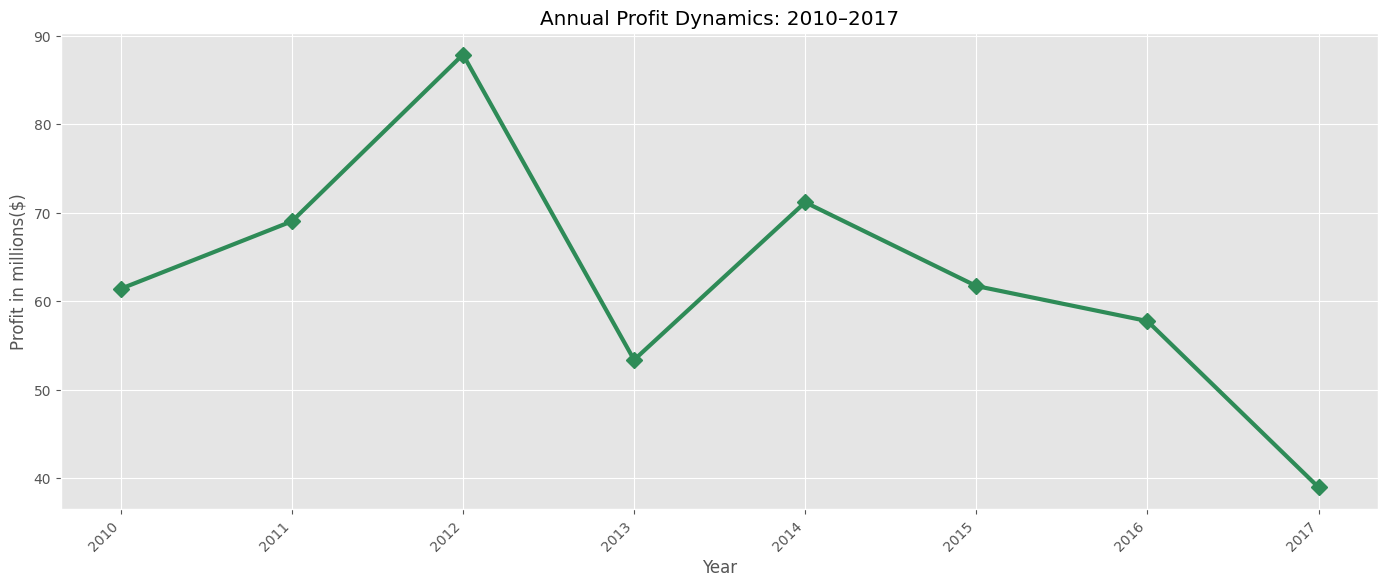

In [ ]:
df2["Year"] = df2["Order_Date"].dt.year
year_gr = df2.groupby("Year")["Profit_M"].sum().reset_index()
plt.figure(figsize=(17, 7))
plt.plot(year_gr["Year"], year_gr["Profit_M"], color="SeaGreen", linewidth=3, marker='D', markersize=8)
plt.title("Annual Profit Dynamics: 2010–2017")
plt.xlabel("Year")
plt.ylabel("Profit in millions($)")
plt.gcf().autofmt_xdate(rotation=45)
plt.show()

From 2010 to 2012, profit showed consistent growth, rising from approximately 61 million \$ in 2010 to an absolute peak in 2012, when annual profit reached nearly 88 million \$. This peak was followed by a sharp decline in 2013, with figures dropping to 54 million \$. A strong recovery was observed in 2014, as profit climbed back to over 70 million \$. However, following 2014, the business experienced a gradual but steady downturn. By 2017, profit reached an absolute minimum of approximately 39 million \$, though it should be noted that the 2017 dataset only includes figures through September.

#Profit Dynamics by Product Category

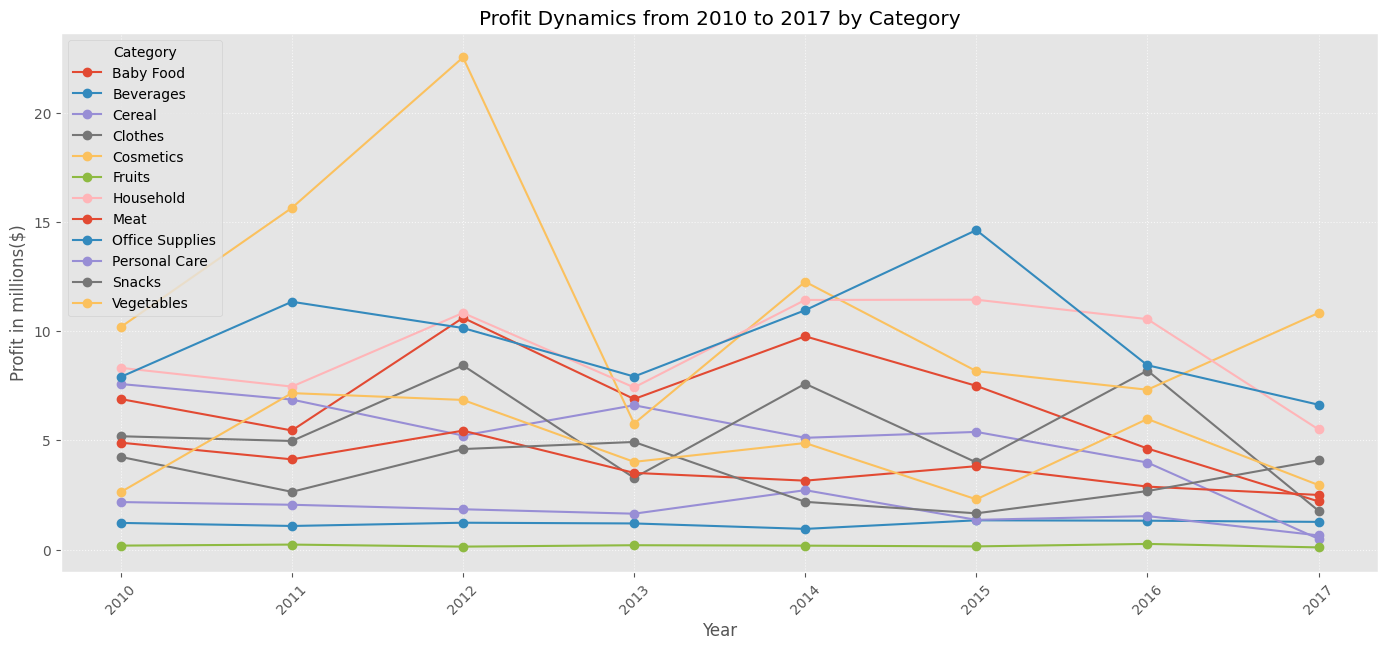

In [ ]:
year_group = df2.groupby(["Year", "Product"])["Profit_M"].sum().reset_index()
plt.figure(figsize=(17, 7))
products = year_group["Product"].unique()
for product in products:
    subset = year_group[year_group["Product"] == product]
    plt.plot(
        subset["Year"],
        subset["Profit_M"],
        label=product,
        marker='o',
        linestyle='-'
    )
plt.title("Profit Dynamics from 2010 to 2017 by Category")
plt.xlabel("Year")
plt.ylabel("Profit in millions($)")
plt.legend(title="Category", loc="upper left")
plt.xticks(year_group["Year"].unique(), rotation=45)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Due to the visual complexity of the full category chart, a detailed analysis of the most profitable product categories was conducted.

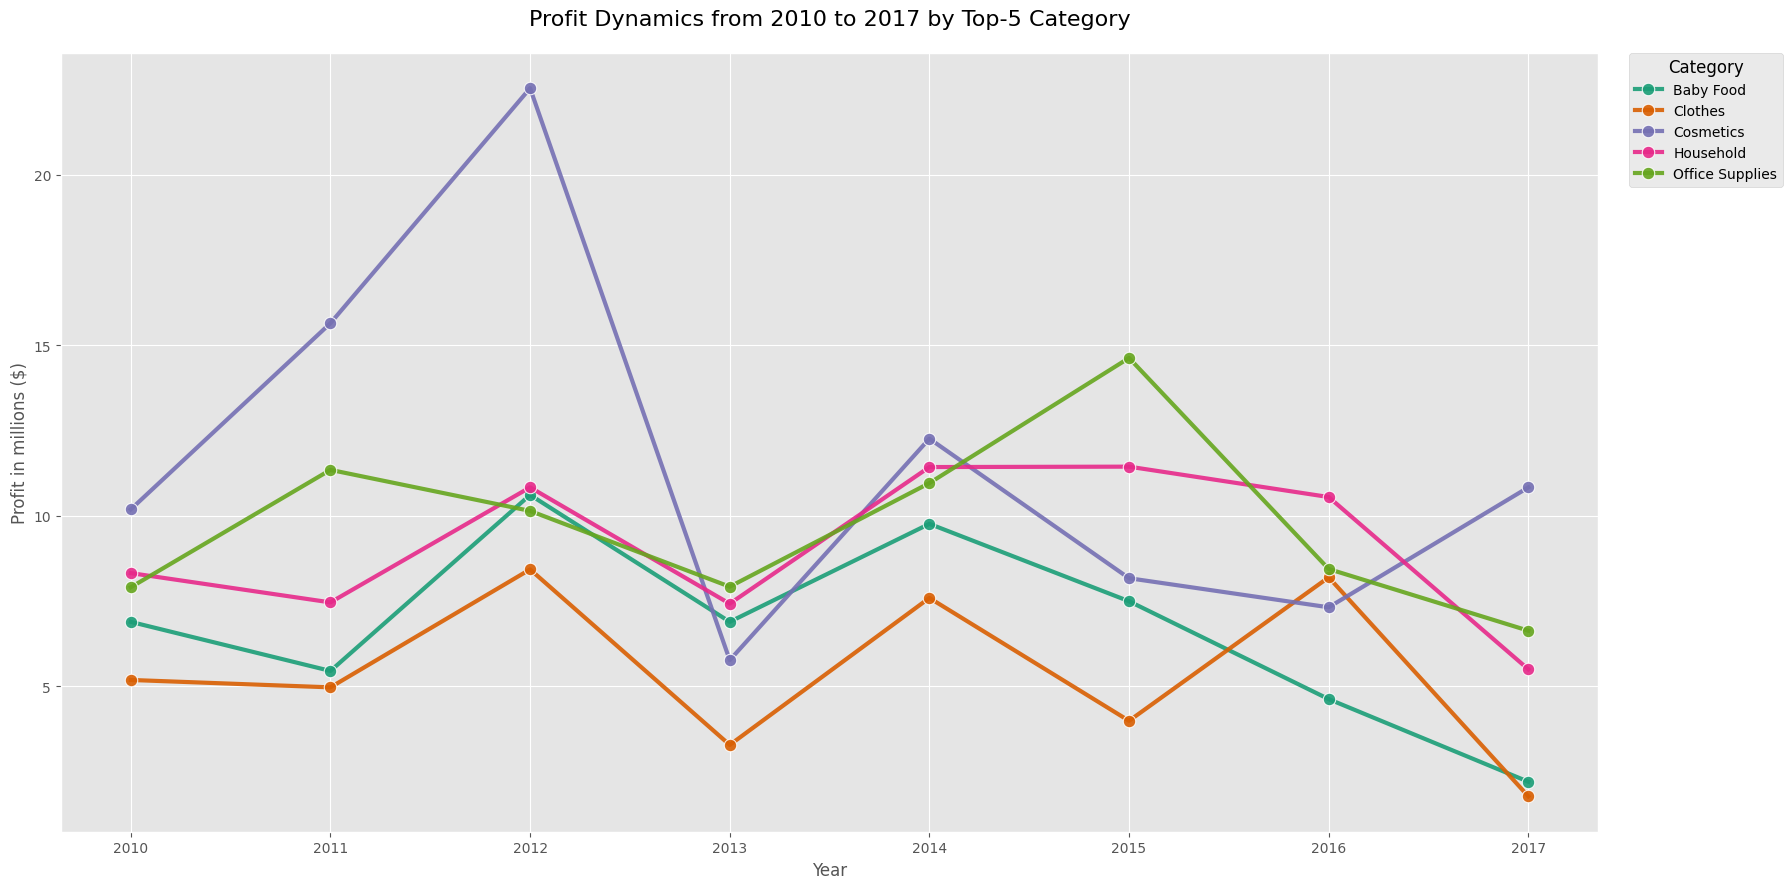

In [ ]:
profit_by_product = year_group.groupby("Product")["Profit_M"].sum()
top_5_products = profit_by_product.nlargest(5).index.tolist()
year_group_top5 = year_group[year_group["Product"].isin(top_5_products)]
plt.figure(figsize=(18, 9))
sns.lineplot(
    data=year_group_top5,
    x="Year",
    y="Profit_M",
    hue="Product",
    marker='o',
    markersize=9,
    linewidth=3,
    alpha=0.9,
    palette='Dark2'
)

plt.title("Profit Dynamics from 2010 to 2017 by Top-5 Category",
    fontsize=16,
    pad=20
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Profit in millions ($)", fontsize=12)
plt.xticks(year_group_top5["Year"].unique(), fontsize=10)
plt.legend(
    title="Category",
    title_fontsize='12',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=10)
plt.tight_layout()
plt.show()

The Cosmetics category achieved its highest profit levels in 2012, followed by a universal downturn across all categories in 2013. Market stabilization and profit recovery were observed in 2014, while the Office Supplies category reached its peak in 2015. A cyclical pattern of alternating growth and decline is evident across all segments. Notably, the Baby Food category has shown a sharp downward trend since 2014. Conversely, despite periodic fluctuations, Cosmetics demonstrates an overall upward growth trajectory compared to other product groups.

#Profit Dynamics by Country

In [ ]:
year_profit = df2.groupby(["Year", "Country"])["Profit_M"].sum().reset_index()
pivot_table = pd.pivot_table(year_profit, values="Profit_M", index="Country", columns="Year", aggfunc="sum")
pivot_table.head()

Year,2010,2011,2012,2013,2014,2015,2016,2017
Country,,,,,,,,
Albania,2.733095,1.593785,1.805447,0.108213,0.081134,1.406732,2.472439,0.289862
Andorra,3.243222,0.677800,3.423332,1.205157,1.028468,0.580267,4.601389,0.650402
Armenia,1.930235,0.903658,1.179933,0.415254,0.964283,2.072917,1.142531,0.813542
Austria,3.489735,0.839535,0.210538,0.651535,1.056415,3.022173,0.485865,0.271714
Belarus,0.773377,1.875224,1.872339,1.102329,0.904793,2.339000,2.270877,0.714481


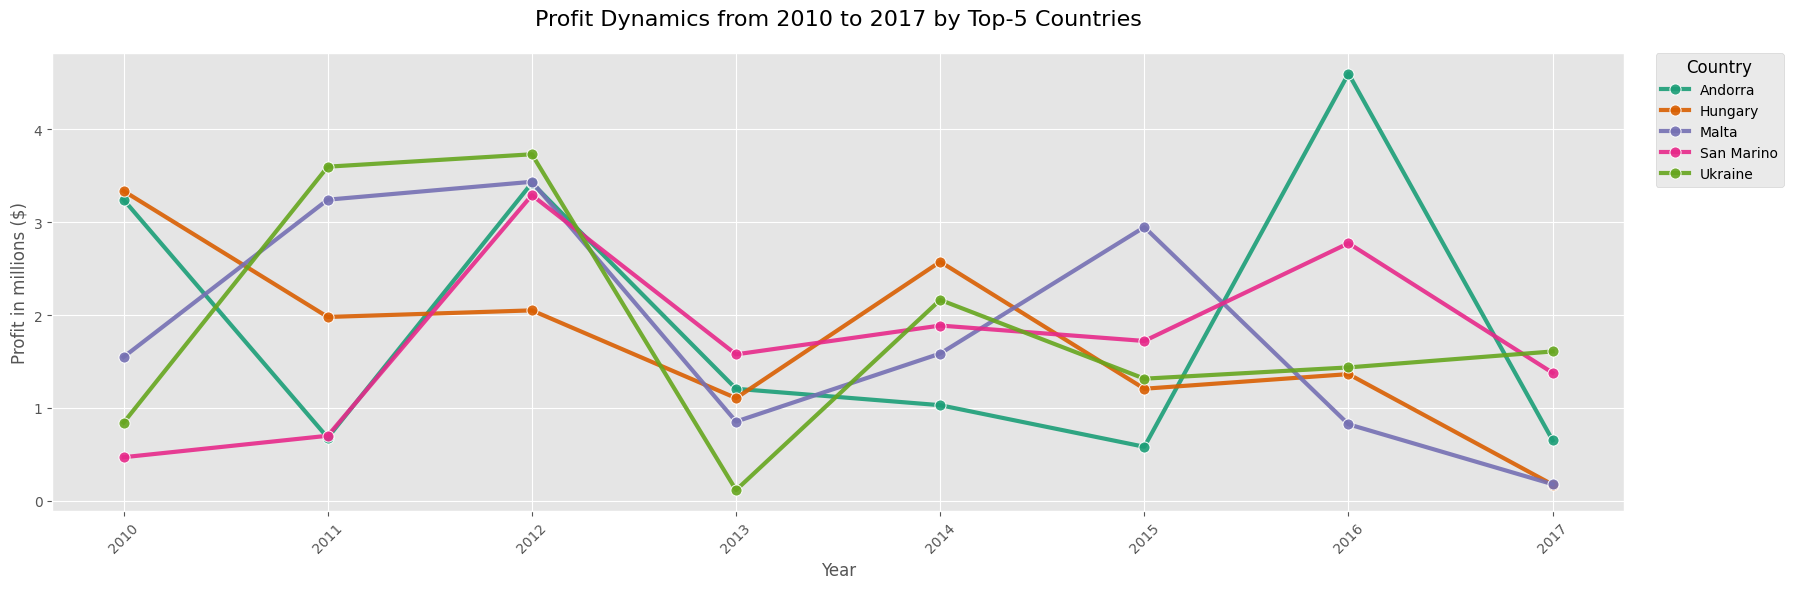

In [ ]:
profit_by_country= year_profit.groupby("Country")["Profit_M"].sum()
top_5_country = profit_by_country.nlargest(5).index.tolist()
country_top5 = year_profit[year_profit["Country"].isin(top_5_country)]
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=country_top5,
    x="Year",
    y="Profit_M",
    hue="Country",
    marker='o',
    markersize=8,
    linewidth=3,
    alpha=0.9,
    palette='Dark2'
)

plt.title("Profit Dynamics from 2010 to 2017 by Top-5 Countries",
    fontsize=16,
    pad=20
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Profit in millions ($)", fontsize=12)
plt.xticks(year_group_top5["Year"].unique(), rotation=45, fontsize=10)
plt.legend(
    title="Country",
    title_fontsize='12',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=10)
plt.tight_layout()
plt.show()

Between 2010 and 2013, Ukraine and Malta exhibited similar upward profit trends. San Marino also showed significant growth during this period. In contrast, Andorra recorded high performance in 2010 and 2012, but experienced a notable downturn in 2011. Together, these four countries contributed to the overall profit peak in 2012. Interestingly, Hungary did not follow this aggressive peaking pattern, maintaining more stable figures without the sharp decline in 2013 seen elsewhere. While 2014 served as a stabilization year with most countries recovering, Andorra reached its absolute profit peak in 2016 before suffering the most drastic drop in 2017. By late 2017, nearly all top countries showed a downward trend, with Ukraine being the notable exception.

#Profit Dynamics by Sub-region

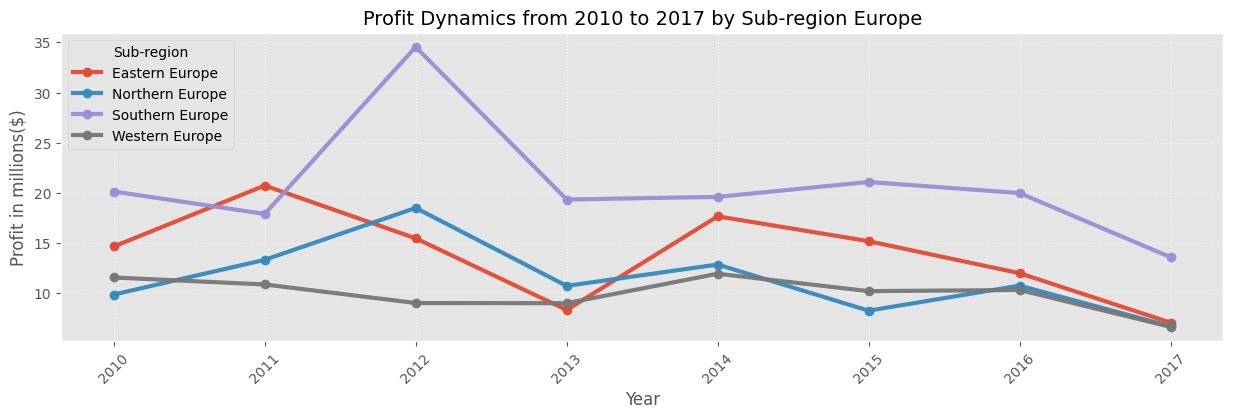

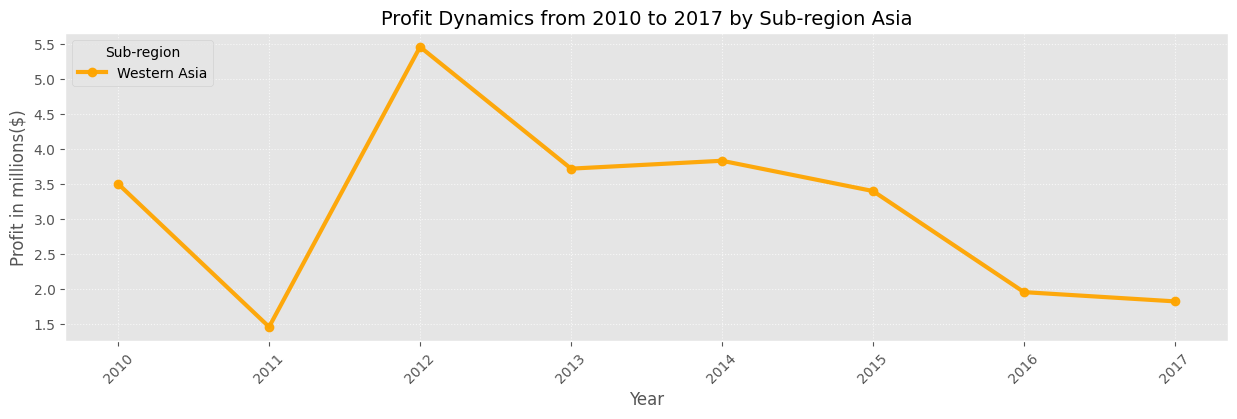

In [ ]:
europe_regions = ['Eastern Europe', 'Northern Europe', 'Southern Europe', 'Western Europe']
year_region = df2.groupby(['Year', 'Sub-region'])['Profit_M'].sum().reset_index()
europe_data = year_region[year_region['Sub-region'].isin(europe_regions)]
asia_data = year_region[year_region['Sub-region'] == 'Western Asia']
plt.figure(figsize=(15, 4))
for subregion in europe_data["Sub-region"].unique():
    subset1 = europe_data[europe_data["Sub-region"] == subregion]
    plt.plot(
        subset1["Year"],
        subset1["Profit_M"],
        label=subregion,
        marker='o',
        linestyle='-',
        markersize=6,
        linewidth=3,
        alpha=0.95,
    )

plt.title("Profit Dynamics from 2010 to 2017 by Sub-region Europe", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Profit in millions($)")
plt.legend(title="Sub-region", loc="upper left")
plt.xticks(year_group["Year"].unique(), rotation=45)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()
plt.figure(figsize=(15, 4))
plt.plot(
    asia_data["Year"],
    asia_data["Profit_M"],
    label="Western Asia",
    marker='o',
    linestyle='-',
    color='orange',
    markersize=6,
    linewidth=3,
    alpha=0.95,
)
plt.title("Profit Dynamics from 2010 to 2017 by Sub-region Asia", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Profit in millions($)")
plt.legend(title="Sub-region", loc="upper left")
plt.xticks(year_group["Year"].unique(), rotation=45)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Eastern Europe stands out as the most profitable region, characterized by an exceptional peak in 2012, which suggests a successful yet likely non-recurring sales cycle during that period. Following 2012, profits stabilized at a high level, though the overall trajectory shows a gradual decline toward 2017. In terms of long-term stability, Northern, Southern, and Western Europe demonstrate more predictable fluctuations. Since 2014, these regions have maintained steady returns, although all sub-regions concluded 2017 at levels below their initial figures. Meanwhile, Western Asia experienced a significant surge in 2012, followed by a sustained downturn, reaching its lowest point by 2017.

#Weekly Profit Dynamics by Product Category

In [ ]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday']
df2["Day_week"] = df2["Order_Date"].dt.day_name()
df2["Day_week"]= pd.Categorical(
    df2["Day_week"],
    categories=day_order,
    ordered=True)
group_weekdays = df2.groupby("Day_week", observed=False)["Profit_M"].agg(["sum", "mean"]).reset_index()
group_weekday = df2.groupby(["Day_week", "Product"], observed=False)["Profit_M"].sum().reset_index().sort_values(by="Profit_M", ascending=False)
group_weekdays


,Day_week,sum,mean
0,Monday,75.790330,0.377066
1,Tuesday,65.637400,0.360645
2,Wednesday,72.323843,0.372803
3,Thursday,64.325663,0.385184
4,Friday,79.234529,0.450196
5,Saturday,71.435860,0.355402
6,Sunday,72.686833,0.351144


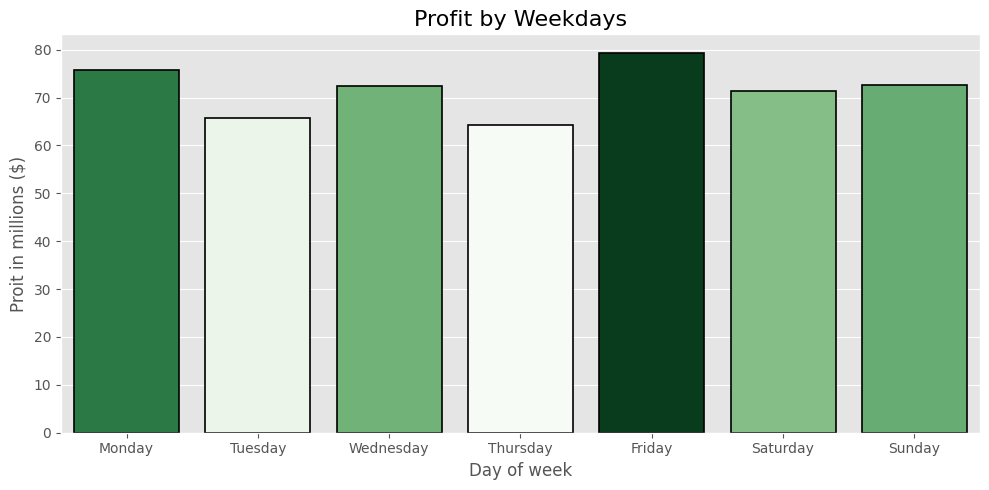

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x="Day_week",
    y="sum",
    hue="sum",
    data=group_weekdays,
    palette="Greens",
    edgecolor="black",
    linewidth=1.2
)
plt.title("Profit by Weekdays", fontsize=16)
plt.xlabel("Day of week", fontsize=12)
plt.ylabel("Proit in millions ($)", fontsize=12)
plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

The company generates its highest profit on Fridays, with figures approaching nearly 80 million \$. Other strong performance peaks are observed on Mondays and Wednesdays. Weekends demonstrate moderately high profit levels, with Sunday slightly outperforming Saturday. The lowest profit margins are recorded on Tuesdays and Thursdays, where totals barely exceed 60 million \$. Overall, despite these noticeable fluctuations, the company maintains a consistently high profit baseline throughout the entire week.

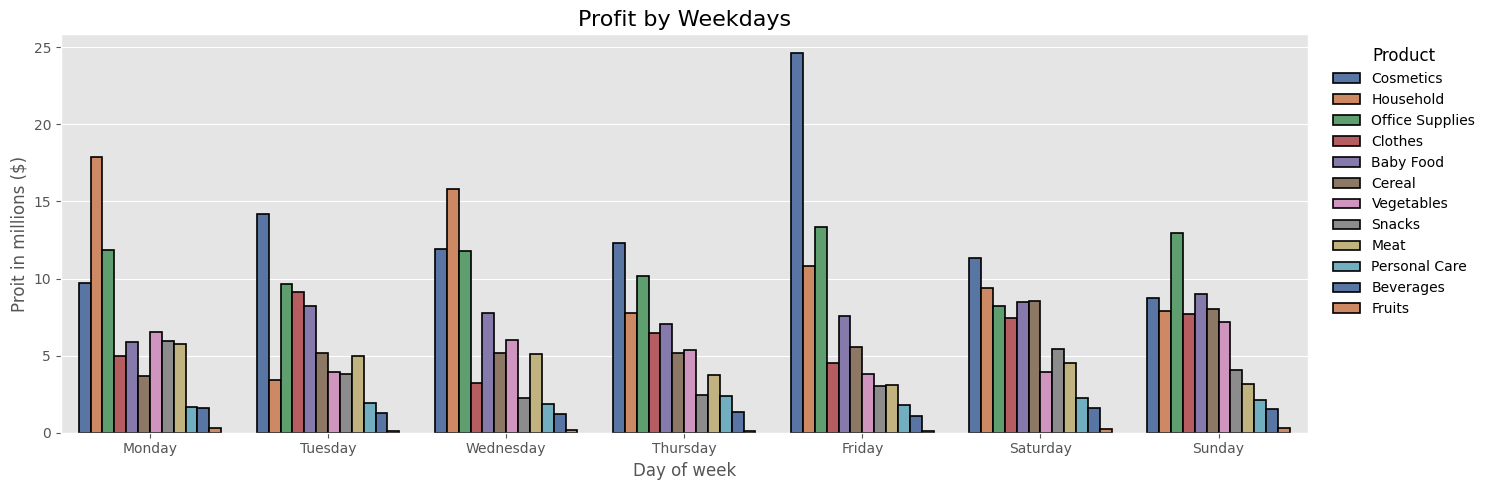

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(
    x="Day_week",
    y="Profit_M",
    hue="Product",
    data=group_weekday,
    palette="deep",
    edgecolor="black",
    linewidth=1.2
)
plt.title("Profit by Weekdays", fontsize=16)
plt.xlabel("Day of week", fontsize=12)
plt.ylabel("Proit in millions ($)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    title="Product",
    title_fontsize='12',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=10,
    frameon=False
)
plt.tight_layout()
plt.show()

Daily Insights:
*   Monday sees strong performance in the Household category (approx. 17.5 million \$), making it the strongest day for this segment, alongside significant contributions from Office Supplies and Cosmetics.
*   Tuesday is led by Cosmetics (approx. 14.5 million \$), followed by Office Supplies, while Household sales underperform on this day.
*   Wednesday shows peak profitability across Household, Office Supplies, and Cosmetics, marking a significant day for these core products.
*   Thursday maintains high returns in Cosmetics, Office Supplies, and Household.
*   Friday records the highest total profit of the week, a peak driven entirely by Cosmetics, which sees a massive surge to nearly 24.5 million \$.
*   Weekends see a decline in leading categories; Cosmetics and Household lead on Saturday, while Sunday exhibits a unique peak in Office Supplies and Baby Food.

Category-Specific Insights:
*   Cosmetics: The absolute profit leader on most days (Tue, Thu, Fri, Sat), reaching its maximum on Friday.
*   Household: Exhibits peaks on Monday, Wednesday, and Friday, with Monday being the most profitable.
*   Office Supplies: Maintains stable, high performance throughout the week, peaking on Friday and Sunday.
*   Clothes: Shows high total profit on Tuesday, Saturday, and Sunday, with the weekly high occurring on Tuesday.
*   Baby Food: Most profitable on Sunday, Saturday, and Tuesday; Monday is the weakest day for this category.
*   Other Segments: Cereal performs best over the weekend, Vegetables peak on Sunday and Monday, Snacks on Monday and Saturday, and Meat on Monday.

#General Conclusion

**Regional Performance**  
The company’s operations are characterized by high profitability in Europe, with a total revenue of 1,500 million \$ and 450 million \$ in profit. Within this dominant region, Eastern Europe remains the primary profit driver, although its performance has remained inconsistent with a gradual downward trend since the absolute peak in 2012.

**Category Analysis**  
While Office Supplies, Household, and Cosmetics are the revenue leaders, Cosmetics is the definitive leader in profit due to its highly efficient low-cost structure. Similarly, the Clothes category maintains high profitability despite lower revenue levels, whereas the Meat category continues to lose ground due to excessively high production costs.

**Seasonality and Trends**  
Weekly analysis identifies Friday as the most profitable day, while Tuesdays and Thursdays consistently record the lowest profit figures. Overall, profits exhibit a strong cyclical nature, marked by a significant peak in 2012, a sharp contraction in 2013, and a general downward trajectory leading into late 2017.

**Sales Channels and Pricing**  
Offline orders maintain a lead in gross revenue, yet the profit gap between offline and online channels remains minimal due to higher offline overhead costs.
Price distribution confirms a dual-segment strategy, where a dominant budget segment is complemented by a premium category that effectively sustains the average unit price.

#Recommendations

**Development of Profit Laeders**  
Since the *cosmetics* category stands as the absolute profit leader, it must remain a top strategic priority for the business. It is essential to identify the root causes behind its high margins and apply these best practices, such as successful cost management or effective pricing models, to other product lines.
The *clothes* category also shows significant untapped potential that is currently not fully reflected in the total revenue figures. To address this, marketing efforts and online presence should be increased, specifically targeting peak sales days such as Tuesday and the weekends when performance is highest.

**Cost Optimization**  
A comprehensive audit of the supply chain and operational expenses for the *meat* category is required to restore its profitability. Reducing the high costs that currently offset the substantial revenue volume generated by this segment is critical for its future financial health.

**Premium Segment Strategy**  
The company should develop a dedicated marketing strategy for high-priced products to better leverage premium tier utilization. Since these items significantly drive the average revenue, it is important to focus on high-value customers and specialized sales channels tailored specifically to this premium segment.

**Regional Strategy**  
It is necessary to investigate the factors behind the declining profit trend in Eastern Europe observed since 2012, with the goal of stabilizing profit levels at 2014 benchmarks through targeted market retention strategies.  
Additionally, as the low profitability in Asia indicates insufficient market penetration, a pilot project should be launched in the Western Asia region focused on introducing and promoting established profit leaders like cosmetics and office supplies.

**Optimizing Low-Activity Days**  
To address the lower profit levels recorded on Tuesdays and Thursdays, the company should implement targeted mid-week promotional campaigns. Focusing on high-margin categories during these specific days will help stimulate sales and ensure a more balanced profit distribution throughout the entire week.